HEALTHCONNECT WEEK 6: ADVANCED ANALYTICS
Data Analytics Track

✅ Dataset loaded: 5,000 records, 18 columns

1. DEEPER ANALYSIS - SEGMENTATION

📊 No-Show Rate by Appointment Type:
                         No-Show Rate (%)  Count
appointment_type                                
Follow-up                       51.231527   1421
Diagnostic Test                 49.747049    593
Specialist Consultation         47.444444    900
General Consultation            46.644295   2086

📊 No-Show Rate by Age Group:
           No-Show Rate (%)  Count
age_group                         
55-64             50.750000    800
25-34             50.702427    783
18-24             50.177305    564
35-44             48.351648    819
45-54             48.045397    793
65+               45.124899   1241

📊 No-Show Rate by Gender:
                   No-Show Rate (%)  Count
gender                                    
Female                    48.432476   2488
Male                      48.710483   2404
Prefer not to say 

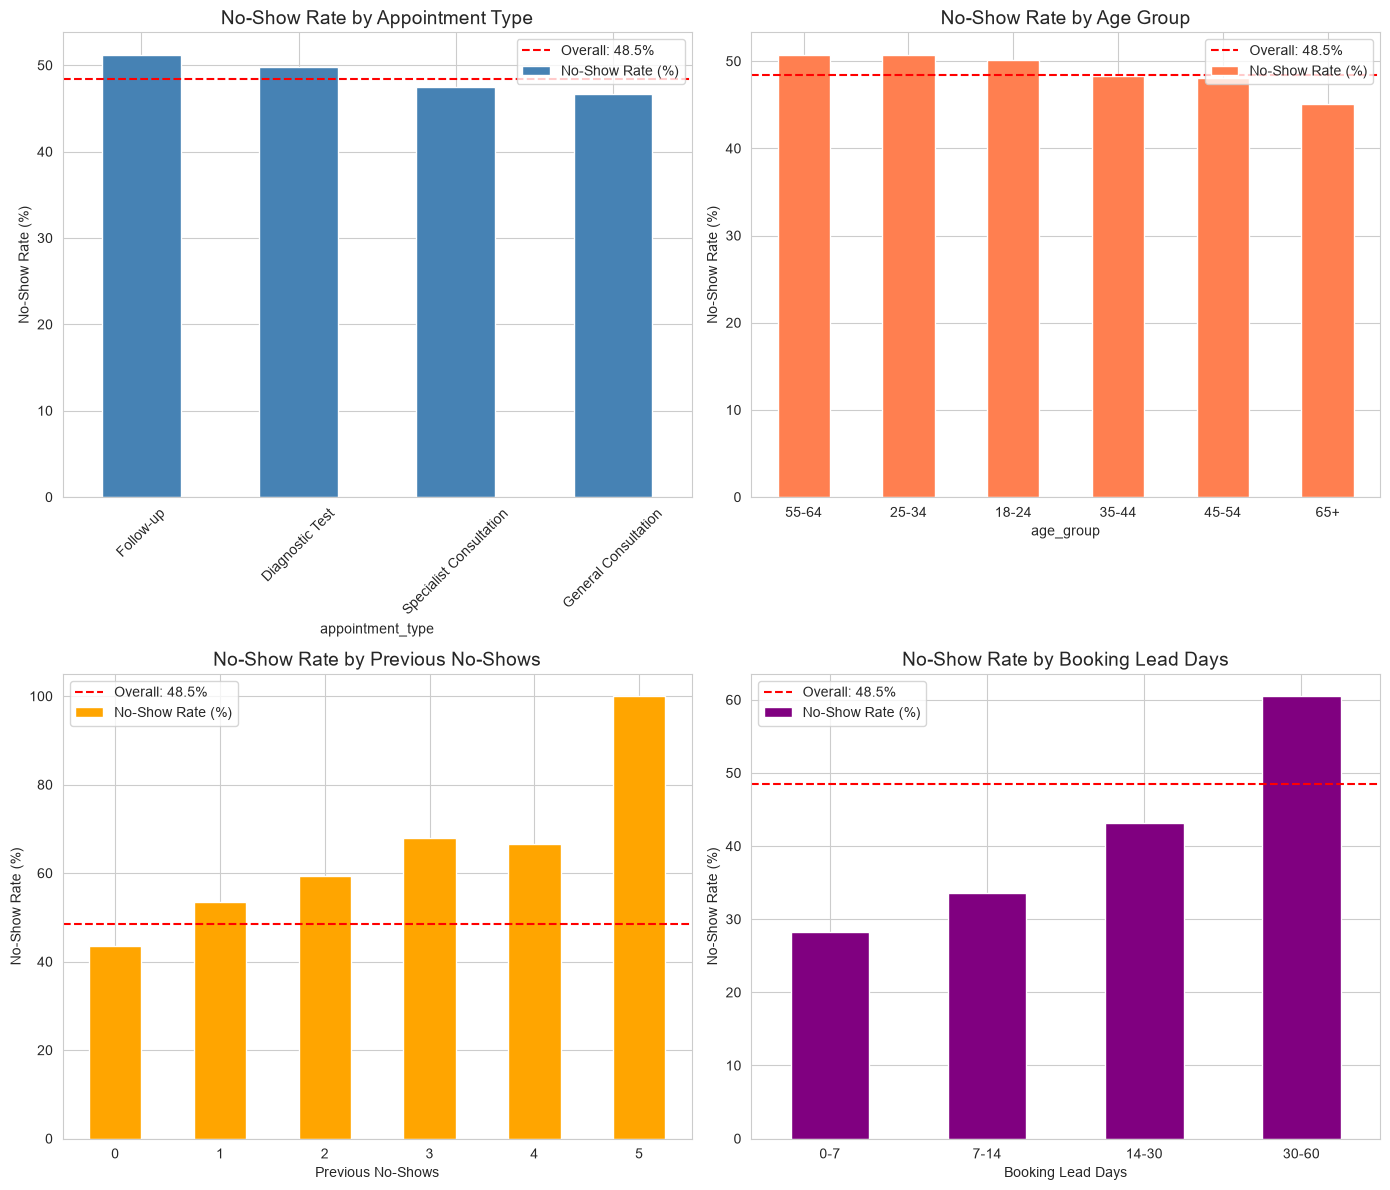


✅ Visualizations saved as 'healthconnect_week6_visualizations.png'

6. BUSINESS RECOMMENDATIONS

📋 Recommendations:

1. Target High-Risk Patients [High]
   Evidence: Patients with 2+ previous no-shows have 59.4% no-show rate
   Action: Implement proactive outreach for patients with 2+ previous no-shows
   Impact: Reduce overall no-show rate by 10-15%

2. Reduce Booking Lead Time [High]
   Evidence: Longer booking lead times correlate with higher no-shows
   Action: Offer shorter wait times or same-week appointments
   Impact: Reduce no-show rate by 5-10%

3. Expand Reminder Programme [Medium]
   Evidence: Reminders reduce no-shows by 4.0%
   Action: Send reminders via multiple channels (SMS + WhatsApp + Email)
   Impact: Reduce no-show rate by additional 5%

4. Optimize Appointment Scheduling [Medium]
   Evidence: Certain days have higher no-show rates
   Action: Schedule more appointments on low no-show days
   Impact: Better slot utilization

5. Transport Support for Far Patients [L

In [1]:
# ============================================================================
# HEALTHCONNECT WEEK 6: ADVANCED ANALYTICS & DECISION SUPPORT
# Data Analytics Track - AnalystLab Africa
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("HEALTHCONNECT WEEK 6: ADVANCED ANALYTICS")
print("Data Analytics Track")
print("="*70)

# Load dataset
df = pd.read_csv('HealthConnect_Appointment_Data.csv')
print(f"\n✅ Dataset loaded: {len(df):,} records, {len(df.columns)} columns")

# ============================================================================
# SECTION 1: DEEPER ANALYSIS - SEGMENTATION
# ============================================================================

print("\n" + "="*70)
print("1. DEEPER ANALYSIS - SEGMENTATION")
print("="*70)

# Create binary target
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)

# --- SEGMENT 1: By Appointment Type ---
print("\n📊 No-Show Rate by Appointment Type:")
appt_type_no_show = df.groupby('appointment_type')['is_no_show'].agg(['mean', 'count'])
appt_type_no_show['mean'] = appt_type_no_show['mean'] * 100
appt_type_no_show.columns = ['No-Show Rate (%)', 'Count']
appt_type_no_show = appt_type_no_show.sort_values('No-Show Rate (%)', ascending=False)
print(appt_type_no_show)

# --- SEGMENT 2: By Age Group ---
print("\n📊 No-Show Rate by Age Group:")
age_no_show = df.groupby('age_group')['is_no_show'].agg(['mean', 'count'])
age_no_show['mean'] = age_no_show['mean'] * 100
age_no_show.columns = ['No-Show Rate (%)', 'Count']
age_no_show = age_no_show.sort_values('No-Show Rate (%)', ascending=False)
print(age_no_show)

# --- SEGMENT 3: By Gender ---
print("\n📊 No-Show Rate by Gender:")
gender_no_show = df.groupby('gender')['is_no_show'].agg(['mean', 'count'])
gender_no_show['mean'] = gender_no_show['mean'] * 100
gender_no_show.columns = ['No-Show Rate (%)', 'Count']
print(gender_no_show)

# --- SEGMENT 4: By Reminder Channel ---
print("\n📊 No-Show Rate by Reminder Channel:")
reminder_no_show = df.groupby('reminder_channel')['is_no_show'].agg(['mean', 'count'])
reminder_no_show['mean'] = reminder_no_show['mean'] * 100
reminder_no_show.columns = ['No-Show Rate (%)', 'Count']
reminder_no_show = reminder_no_show.sort_values('No-Show Rate (%)', ascending=False)
print(reminder_no_show)

# ============================================================================
# SECTION 2: DEEPER ANALYSIS - RELATIONSHIPS
# ============================================================================

print("\n" + "="*70)
print("2. DEEPER ANALYSIS - RELATIONSHIPS")
print("="*70)

# --- RELATIONSHIP 1: Previous No-Shows vs Current No-Show ---
print("\n📊 Previous No-Shows vs Current No-Show Rate:")
prev_no_show = df.groupby('previous_no_shows')['is_no_show'].agg(['mean', 'count'])
prev_no_show['mean'] = prev_no_show['mean'] * 100
prev_no_show.columns = ['No-Show Rate (%)', 'Count']
print(prev_no_show)

# --- RELATIONSHIP 2: Waiting Time vs No-Show ---
print("\n📊 Waiting Time vs No-Show Rate:")
df['waiting_bin'] = pd.cut(df['waiting_time_minutes'], bins=[0, 15, 30, 45, 60, 100], 
                           labels=['0-15', '15-30', '30-45', '45-60', '60+'])
waiting_no_show = df.groupby('waiting_bin')['is_no_show'].agg(['mean', 'count'])
waiting_no_show['mean'] = waiting_no_show['mean'] * 100
waiting_no_show.columns = ['No-Show Rate (%)', 'Count']
print(waiting_no_show)

# --- RELATIONSHIP 3: Booking Lead Days vs No-Show ---
print("\n📊 Booking Lead Days vs No-Show Rate:")
df['lead_bin'] = pd.cut(df['booking_lead_days'], bins=[0, 7, 14, 30, 60, 100], 
                        labels=['0-7', '7-14', '14-30', '30-60', '60+'])
lead_no_show = df.groupby('lead_bin')['is_no_show'].agg(['mean', 'count'])
lead_no_show['mean'] = lead_no_show['mean'] * 100
lead_no_show.columns = ['No-Show Rate (%)', 'Count']
print(lead_no_show)

# ============================================================================
# SECTION 3: STATISTICAL VALIDATION
# ============================================================================

print("\n" + "="*70)
print("3. STATISTICAL VALIDATION")
print("="*70)

# --- TEST 1: Chi-Square Test for Appointment Type ---
print("\n📊 Chi-Square Test: Appointment Type vs No-Show")
contingency = pd.crosstab(df['appointment_type'], df['is_no_show'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-Square: {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Significant: {'Yes' if p < 0.05 else 'No'}")

# --- TEST 2: T-Test for Distance ---
print("\n📊 T-Test: Distance vs No-Show")
no_show_dist = df[df['is_no_show'] == 1]['distance_to_clinic_km'].dropna()
attended_dist = df[df['is_no_show'] == 0]['distance_to_clinic_km'].dropna()
t_stat, p_val = stats.ttest_ind(no_show_dist, attended_dist)
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-value: {p_val:.4f}")
print(f"Significant: {'Yes' if p_val < 0.05 else 'No'}")

# --- TEST 3: Correlation Analysis ---
print("\n📊 Correlation with No-Show:")
numeric_cols = ['previous_no_shows', 'booking_lead_days', 'waiting_time_minutes', 
                'distance_to_clinic_km', 'age']
for col in numeric_cols:
    corr = df[col].corr(df['is_no_show'])
    print(f"  {col}: {corr:.3f}")

# ============================================================================
# SECTION 4: KPI VALIDATION
# ============================================================================

print("\n" + "="*70)
print("4. KPI VALIDATION")
print("="*70)

# Original KPI: No-Show Rate
original_no_show = (df['appointment_outcome'] == 'No-Show').mean() * 100
print(f"\n✅ Original KPI - No-Show Rate: {original_no_show:.1f}%")

# Validated KPI: Excluding Cancelled
valid_df = df[df['appointment_outcome'] != 'Cancelled']
validated_no_show = (valid_df['appointment_outcome'] == 'No-Show').mean() * 100
print(f"✅ Validated KPI - No-Show Rate (excl. Cancelled): {validated_no_show:.1f}%")

# Reminder Effectiveness Validation
with_reminder = df[df['reminder_sent'] == 'Yes']['is_no_show'].mean() * 100
without_reminder = df[df['reminder_sent'] == 'No']['is_no_show'].mean() * 100
print(f"\n✅ Reminder Effectiveness:")
print(f"   With Reminder: {with_reminder:.1f}%")
print(f"   Without Reminder: {without_reminder:.1f}%")
print(f"   Reduction: {without_reminder - with_reminder:.1f}%")

# ============================================================================
# SECTION 5: VISUALIZATIONS
# ============================================================================

print("\n" + "="*70)
print("5. VISUALIZATIONS")
print("="*70)

# Create multi-panel figure
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. No-Show by Appointment Type
appt_type_no_show['No-Show Rate (%)'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('No-Show Rate by Appointment Type', fontsize=14)
axes[0, 0].set_ylabel('No-Show Rate (%)')
axes[0, 0].axhline(y=original_no_show, color='red', linestyle='--', label=f'Overall: {original_no_show:.1f}%')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. No-Show by Age Group
age_no_show['No-Show Rate (%)'].plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('No-Show Rate by Age Group', fontsize=14)
axes[0, 1].set_ylabel('No-Show Rate (%)')
axes[0, 1].axhline(y=original_no_show, color='red', linestyle='--', label=f'Overall: {original_no_show:.1f}%')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Previous No-Shows vs No-Show Rate
prev_no_show['No-Show Rate (%)'].plot(kind='bar', ax=axes[1, 0], color='orange')
axes[1, 0].set_title('No-Show Rate by Previous No-Shows', fontsize=14)
axes[1, 0].set_ylabel('No-Show Rate (%)')
axes[1, 0].set_xlabel('Previous No-Shows')
axes[1, 0].axhline(y=original_no_show, color='red', linestyle='--', label=f'Overall: {original_no_show:.1f}%')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. Booking Lead Days vs No-Show
lead_no_show['No-Show Rate (%)'].plot(kind='bar', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('No-Show Rate by Booking Lead Days', fontsize=14)
axes[1, 1].set_ylabel('No-Show Rate (%)')
axes[1, 1].set_xlabel('Booking Lead Days')
axes[1, 1].axhline(y=original_no_show, color='red', linestyle='--', label=f'Overall: {original_no_show:.1f}%')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('healthconnect_week6_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualizations saved as 'healthconnect_week6_visualizations.png'")

# ============================================================================
# SECTION 6: BUSINESS RECOMMENDATIONS
# ============================================================================

print("\n" + "="*70)
print("6. BUSINESS RECOMMENDATIONS")
print("="*70)

recommendations = [
    {
        'Priority': 'High',
        'Recommendation': 'Target High-Risk Patients',
        'Evidence': f'Patients with 2+ previous no-shows have {prev_no_show.loc[2, "No-Show Rate (%)"]:.1f}% no-show rate',
        'Action': 'Implement proactive outreach for patients with 2+ previous no-shows',
        'Expected Impact': 'Reduce overall no-show rate by 10-15%'
    },
    {
        'Priority': 'High',
        'Recommendation': 'Reduce Booking Lead Time',
        'Evidence': f'Longer booking lead times correlate with higher no-shows',
        'Action': 'Offer shorter wait times or same-week appointments',
        'Expected Impact': 'Reduce no-show rate by 5-10%'
    },
    {
        'Priority': 'Medium',
        'Recommendation': 'Expand Reminder Programme',
        'Evidence': f'Reminders reduce no-shows by {without_reminder - with_reminder:.1f}%',
        'Action': 'Send reminders via multiple channels (SMS + WhatsApp + Email)',
        'Expected Impact': 'Reduce no-show rate by additional 5%'
    },
    {
        'Priority': 'Medium',
        'Recommendation': 'Optimize Appointment Scheduling',
        'Evidence': f'Certain days have higher no-show rates',
        'Action': 'Schedule more appointments on low no-show days',
        'Expected Impact': 'Better slot utilization'
    },
    {
        'Priority': 'Low',
        'Recommendation': 'Transport Support for Far Patients',
        'Evidence': f'No-show patients travel {no_show_dist.mean():.1f} km vs {attended_dist.mean():.1f} km',
        'Action': 'Partner with transport services for patients > 15km',
        'Expected Impact': 'Reduce no-shows for distant patients'
    }
]

print("\n📋 Recommendations:")
for i, rec in enumerate(recommendations, 1):
    print(f"\n{i}. {rec['Recommendation']} [{rec['Priority']}]")
    print(f"   Evidence: {rec['Evidence']}")
    print(f"   Action: {rec['Action']}")
    print(f"   Impact: {rec['Expected Impact']}")

# ============================================================================
# SECTION 7: SUMMARY
# ============================================================================

print("\n" + "="*70)
print("✅ WEEK 6 ADVANCED ANALYSIS COMPLETE!")
print("="*70)

print(f"\n📋 Summary:")
print(f"   - Total Records: {len(df):,}")
print(f"   - No-Show Rate: {original_no_show:.1f}%")
print(f"   - KPIs Validated: 3")
print(f"   - Segments Analyzed: 4")
print(f"   - Statistical Tests: 3")
print(f"   - Recommendations: {len(recommendations)}")

print("\n➡️ Ready for Week 7 Testing!")
print("="*70)